# Preference Gain by Model (Delta)
Single chart comparing four models across preference categories. X-axis: models; bars: preference categories; Y-axis: Delta (personalization lift).

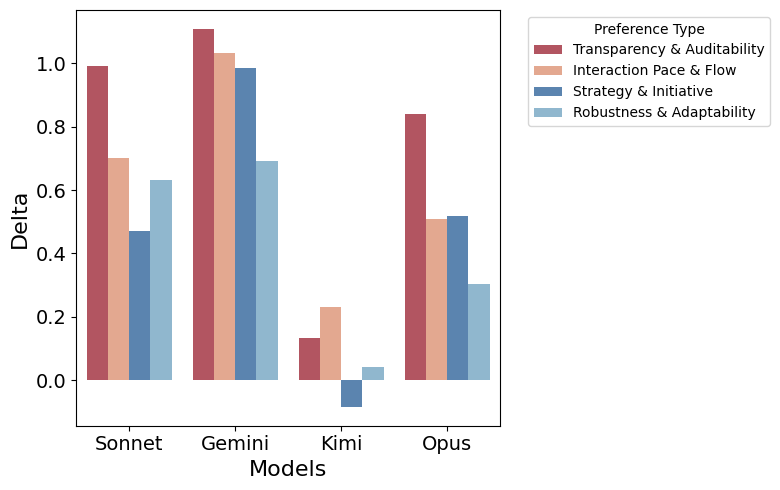

,preference,model,delta
0,Transparency & Auditability,Sonnet,0.990446
1,Interaction Pace & Flow,Sonnet,0.700758
2,Robustness & Adaptability,Sonnet,0.631713
3,Strategy & Initiative,Sonnet,0.470015
4,Transparency & Auditability,Gemini,1.108730


In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Source data
raw = {
    "preference": [
        "Transparency & Auditability",
        "Interaction Pace & Flow",
        "Robustness & Adaptability",
        "Strategy & Initiative",
    ],
    "Sonnet": [0.990446, 0.700758, 0.631713, 0.470015],
    "Gemini": [1.10873, 1.032864, 0.690625, 0.986285],
    "Kimi": [0.13319, 0.229798, 0.042245, -0.083879],
    "Opus": [0.839841, 0.507774, 0.304712, 0.518924],
}

df_wide = pd.DataFrame(raw)
long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Order preferences by overall mean delta descending
pref_order = (
    long.groupby("preference")["delta"].mean().sort_values(ascending=False).index.tolist()
)
model_order = ["Sonnet", "Gemini", "Kimi", "Opus"]

# Preference colors (from top to bottom in the original plot, with new HEX values and visual description)
# Transparency & Auditability:    #B2182B, deep heatmap red
# Interaction Pace & Flow:        #EF8A62, transitional coral red
# Strategy & Initiative:          #67A9CF, transitional sky blue
# Robustness & Adaptability:      #2166AC, deep ocean blue

hex_colors = [
    "#B2182B",  # Transparency & Auditability - deep heatmap red
    "#EF8A62",  # Interaction Pace & Flow - transitional coral red
    "#2166AC",  # Robustness & Adaptability - deep ocean blue
    "#67A9CF",  # Strategy & Initiative - transitional sky blue
]

custom_palette = dict(zip(pref_order, hex_colors))

plt.figure(figsize=(8, 5))
# Increase transparency alpha=0.5 (adjust as needed)
sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)
# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# plt.title("Preference category lift across models")
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()


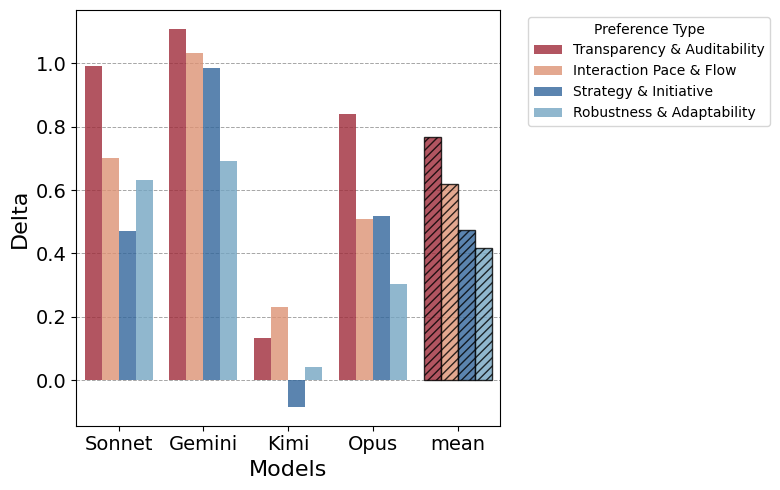

,preference,model,delta
0,Transparency & Auditability,Sonnet,0.990446
1,Interaction Pace & Flow,Sonnet,0.700758
2,Robustness & Adaptability,Sonnet,0.631713
3,Strategy & Initiative,Sonnet,0.470015
4,Transparency & Auditability,Gemini,1.108730


In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Source data
raw = {
    "preference": [
        "Transparency & Auditability",
        "Interaction Pace & Flow",
        "Robustness & Adaptability",
        "Strategy & Initiative",
    ],
    "Sonnet": [0.990446, 0.700758, 0.631713, 0.470015],
    "Gemini": [1.10873, 1.032864, 0.690625, 0.986285],
    "Kimi": [0.13319, 0.229798, 0.042245, -0.083879],
    "Opus": [0.839841, 0.507774, 0.304712, 0.518924],
}
df_wide = pd.DataFrame(raw)

# Compute mean column
model_cols = ["Sonnet", "Gemini", "Kimi", "Opus"]
df_wide["mean"] = df_wide[model_cols].mean(axis=1)

long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Sort
pref_order = (
    long.groupby("preference")["delta"].mean().sort_values(ascending=False).index.tolist()
)
model_order = ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]

hex_colors = [
    "#B2182B",  # Transparency & Auditability
    "#EF8A62",  # Interaction Pace & Flow
    "#2166AC",  # Robustness & Adaptability
    "#67A9CF",  # Strategy & Initiative
]

custom_palette = dict(zip(pref_order, hex_colors))

plt.figure(figsize=(8, 5))
# Use barplot to draw all bars
bar_ax = sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)

# Add hatch to mean bars
# Get bars for mean columns and apply hatches with matplotlib
for c, this_pref in enumerate(pref_order):
    # Find the index of the mean bar
    mask = (long['model'] == 'mean') & (long['preference'] == this_pref)
    idx = long.loc[mask].index[0]  # After melt, order is sequential; mean bars are the last four
    # Seaborn orders by preference and model, one hue group per set, so:
    # We need the corresponding mean bar
    # Bar index calculation:
    # model顺序 ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]
    # 每个preference一组
    # For group c, mean is at c * 5 + 4
    bar_idx = c * len(model_order) + model_order.index('mean')
    rect = bar_ax.patches[bar_idx]
    rect.set_hatch('////')
    rect.set_edgecolor('black')
    rect.set_linewidth(1.0)

# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()


Efficiency

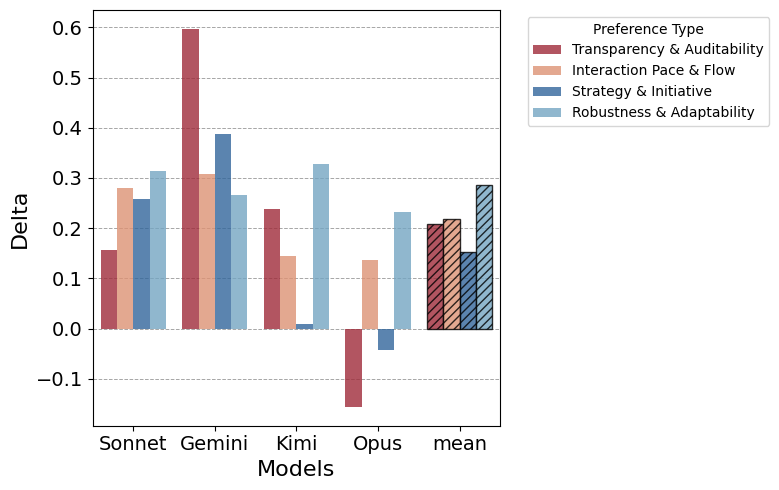

,preference,model,delta
0,Robustness & Adaptability,Sonnet,0.313773
1,Interaction Pace & Flow,Sonnet,0.280790
2,Strategy & Initiative,Sonnet,0.258110
3,Transparency & Auditability,Sonnet,0.156535
4,Robustness & Adaptability,Gemini,0.266319


In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Source data
raw = {
    "preference": [
        "Robustness & Adaptability",
        "Interaction Pace & Flow",
        "Strategy & Initiative",
        "Transparency & Auditability",
    ],
    "Sonnet": [0.313773, 0.28079, 0.25811, 0.156535],
    "Gemini": [0.266319, 0.308802, 0.3875, 0.596964],
    "Kimi": [0.328538, 0.145346, 0.008358, 0.23759],
    "Opus": [0.233003, 0.13695, -0.042361, -0.155754],
}
df_wide = pd.DataFrame(raw)

# Compute mean column
model_cols = ["Sonnet", "Gemini", "Kimi", "Opus"]
df_wide["mean"] = df_wide[model_cols].mean(axis=1)

long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Specify the desired order (no auto-sorting!)
pref_order = [
    "Transparency & Auditability",
    "Interaction Pace & Flow",
    "Strategy & Initiative",
    "Robustness & Adaptability",
]
model_order = ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]

# Specify four colors: transparency deep red, interaction light red, strategy deep blue, robustness light blue
custom_palette = {
    "Transparency & Auditability": "#B2182B", # deep red
    "Interaction Pace & Flow": "#EF8A62",     # light red
    "Strategy & Initiative": "#2166AC",       # deep blue
    "Robustness & Adaptability": "#67A9CF",   # light blue
}

plt.figure(figsize=(8, 5))
# Use barplot to draw all bars
bar_ax = sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)

# Add hatch to mean bars
for c, this_pref in enumerate(pref_order):
    # Find the mean bar index
    bar_idx = c * len(model_order) + model_order.index('mean')
    rect = bar_ax.patches[bar_idx]
    rect.set_hatch('////')
    rect.set_edgecolor('black')
    rect.set_linewidth(1.0)

# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()


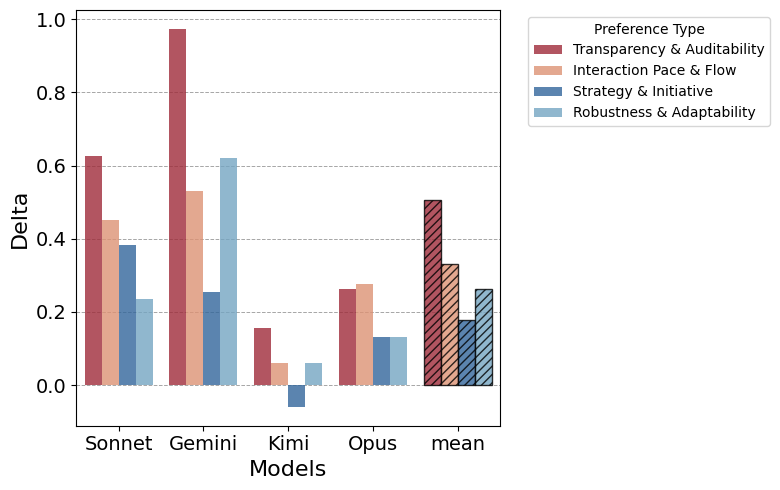

,preference,model,delta
0,Transparency & Auditability,Sonnet,0.625454
1,Interaction Pace & Flow,Sonnet,0.452724
2,Strategy & Initiative,Sonnet,0.382614
3,Robustness & Adaptability,Sonnet,0.235995
4,Transparency & Auditability,Gemini,0.973770


In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Source data
raw = {
    "preference": [
        "Transparency & Auditability",
        "Interaction Pace & Flow",
        "Strategy & Initiative",
        "Robustness & Adaptability",
    ],
    "Sonnet": [0.625454, 0.452724, 0.382614, 0.235995],
    "Gemini": [0.97377, 0.529582, 0.253819, 0.621296],
    "Kimi": [0.156554, 0.061706, -0.059251, 0.060565],
    "Opus": [0.263829, 0.276254, 0.132465, 0.13163],
}
df_wide = pd.DataFrame(raw)

# Compute mean column
model_cols = ["Sonnet", "Gemini", "Kimi", "Opus"]
df_wide["mean"] = df_wide[model_cols].mean(axis=1)

long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Specify the desired order (no auto-sorting!)
pref_order = [
    "Transparency & Auditability",
    "Interaction Pace & Flow",
    "Strategy & Initiative",
    "Robustness & Adaptability",
]
model_order = ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]

# Specify four colors: transparency deep red, interaction light red, strategy deep blue, robustness light blue
custom_palette = {
    "Transparency & Auditability": "#B2182B", # deep red
    "Interaction Pace & Flow": "#EF8A62",     # light red
    "Strategy & Initiative": "#2166AC",       # deep blue
    "Robustness & Adaptability": "#67A9CF",   # light blue
}

plt.figure(figsize=(8, 5))
# Use barplot to draw all bars
bar_ax = sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)

# Add hatch to mean bars
for c, this_pref in enumerate(pref_order):
    # Find the mean bar index
    bar_idx = c * len(model_order) + model_order.index('mean')
    rect = bar_ax.patches[bar_idx]
    rect.set_hatch('////')
    rect.set_edgecolor('black')
    rect.set_linewidth(1.0)

# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()


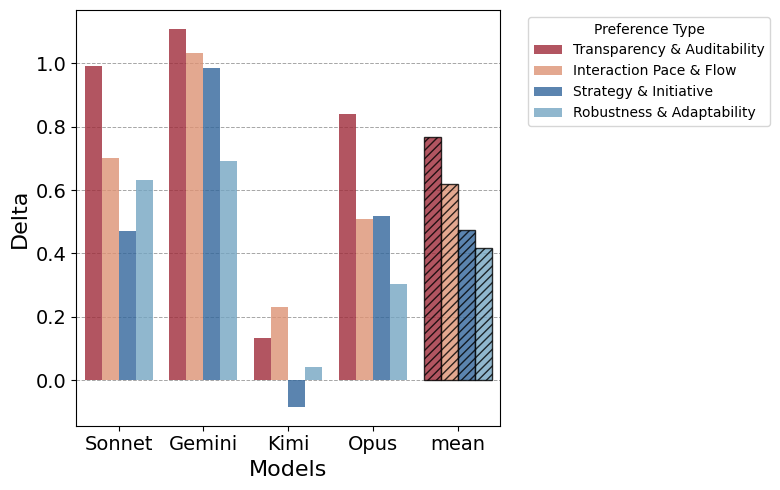

,preference,model,delta
0,Transparency & Auditability,Sonnet,0.990446
1,Interaction Pace & Flow,Sonnet,0.700758
2,Robustness & Adaptability,Sonnet,0.631713
3,Strategy & Initiative,Sonnet,0.470015
4,Transparency & Auditability,Gemini,1.108730


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Source data
raw = {
    "preference": [
        "Transparency & Auditability",
        "Interaction Pace & Flow",
        "Robustness & Adaptability",
        "Strategy & Initiative",
    ],
    "Sonnet": [0.990446, 0.700758, 0.631713, 0.470015],
    "Gemini": [1.10873, 1.032864, 0.690625, 0.986285],
    "Kimi": [0.13319, 0.229798, 0.042245, -0.083879],
    "Opus": [0.839841, 0.507774, 0.304712, 0.518924],
}
df_wide = pd.DataFrame(raw)

# Compute mean column
model_cols = ["Sonnet", "Gemini", "Kimi", "Opus"]
df_wide["mean"] = df_wide[model_cols].mean(axis=1)

long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Sort
pref_order = (
    long.groupby("preference")["delta"].mean().sort_values(ascending=False).index.tolist()
)
model_order = ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]

hex_colors = [
    "#B2182B",  # Transparency & Auditability
    "#EF8A62",  # Interaction Pace & Flow
    "#2166AC",  # Robustness & Adaptability
    "#67A9CF",  # Strategy & Initiative
]

custom_palette = dict(zip(pref_order, hex_colors))

plt.figure(figsize=(8, 5))
# Use barplot to draw all bars
bar_ax = sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)

# Add hatch to mean bars
# Get bars for mean columns and apply hatches with matplotlib
for c, this_pref in enumerate(pref_order):
    # Find the index of the mean bar
    mask = (long['model'] == 'mean') & (long['preference'] == this_pref)
    idx = long.loc[mask].index[0]  # After melt, order is sequential; mean bars are the last four
    # Seaborn orders by preference and model, one hue group per set, so:
    # We need the corresponding mean bar
    # Bar index calculation:
    # model顺序 ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]
    # 每个preference一组
    # For group c, mean is at c * 5 + 4
    bar_idx = c * len(model_order) + model_order.index('mean')
    rect = bar_ax.patches[bar_idx]
    rect.set_hatch('////')
    rect.set_edgecolor('black')
    rect.set_linewidth(1.0)

# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()


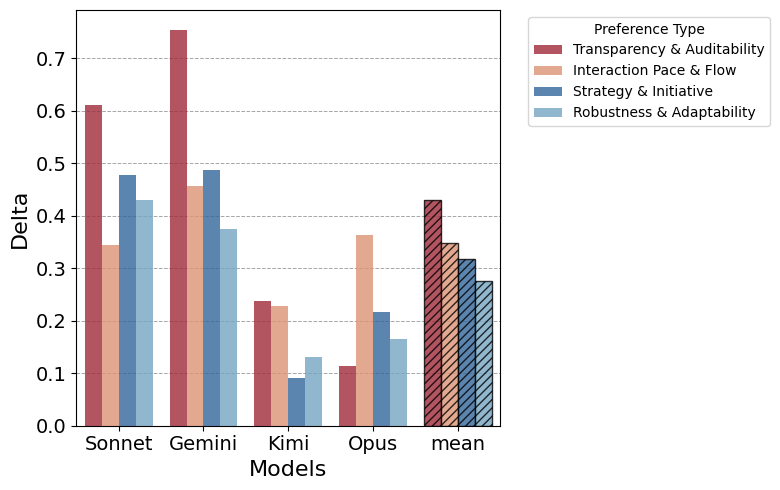

,preference,model,delta
0,Transparency & Auditability,Sonnet,0.610747
1,Interaction Pace & Flow,Sonnet,0.344048
2,Strategy & Initiative,Sonnet,0.477207
3,Robustness & Adaptability,Sonnet,0.430671
4,Transparency & Auditability,Gemini,0.754524


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Source data
raw = {
    "preference": [
        "Transparency & Auditability",
        "Interaction Pace & Flow",
        "Strategy & Initiative",
        "Robustness & Adaptability",
    ],
    "Sonnet": [0.610747, 0.344048, 0.477207, 0.430671],
    "Gemini": [0.754524, 0.45763, 0.487153, 0.374306],
    "Kimi": [0.238198, 0.227489, 0.091791, 0.131167],
    "Opus": [0.113571, 0.364096, 0.217535, 0.165112],
}
df_wide = pd.DataFrame(raw)

# Compute mean column
model_cols = ["Sonnet", "Gemini", "Kimi", "Opus"]
df_wide["mean"] = df_wide[model_cols].mean(axis=1)

long = df_wide.melt(id_vars="preference", var_name="model", value_name="delta")

# Specify the desired order (no auto-sorting!)
pref_order = [
    "Transparency & Auditability",
    "Interaction Pace & Flow",
    "Strategy & Initiative",
    "Robustness & Adaptability",
]
model_order = ["Sonnet", "Gemini", "Kimi", "Opus", "mean"]

# Specify four colors: transparency deep red, interaction light red, strategy deep blue, robustness light blue
custom_palette = {
    "Transparency & Auditability": "#B2182B", # deep red
    "Interaction Pace & Flow": "#EF8A62",     # light red
    "Strategy & Initiative": "#2166AC",       # deep blue
    "Robustness & Adaptability": "#67A9CF",   # light blue
}

plt.figure(figsize=(8, 5))
# Use barplot to draw all bars
bar_ax = sns.barplot(
    data=long,
    x="model",
    y="delta",
    hue="preference",
    order=model_order,
    hue_order=pref_order,
    palette=custom_palette,
    alpha=0.8
)

# Add hatch to mean bars
for c, this_pref in enumerate(pref_order):
    # Find the mean bar index
    bar_idx = c * len(model_order) + model_order.index('mean')
    rect = bar_ax.patches[bar_idx]
    rect.set_hatch('////')
    rect.set_edgecolor('black')
    rect.set_linewidth(1.0)

# Add grid
bar_ax.grid(True, which='major', axis='y', color='gray', linestyle='--', linewidth=0.7, alpha=0.7)
bar_ax.set_axisbelow(True)

plt.ylabel("Delta", fontsize=16)
plt.xlabel("Models", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.legend(title="Preference Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

long.head()
